# **Transformers learn in-context by gradient descent**
This specific notebook can be used to reproduce the results shown in the paper when using the specific token construction i.e. concatinate input and targets i.e. $e_i = (x_i,y_i)$.

In [1]:
import os
import sys
from pathlib import Path
from typing import Any, MutableMapping, NamedTuple, Tuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

import haiku as hk
import optax
from ml_collections import config_dict

import math
import time
import random as pyrandom
from functools import partial

# Optional utilities (safe, pure-Python)
from IPython.display import Image, HTML, clear_output
from tqdm import tqdm

# Verify environment consistency
print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("JAX:", jax.__version__)
print("Devices:", jax.devices())

# Ensure repo root (with ./src) is importable
repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

colors = plt.colormaps["Dark2"]


Python: /Users/jackyue/miniforge3/envs/DSCML/bin/python
NumPy: 2.2.1
JAX: 0.6.2
Devices: [CpuDevice(id=0)]


In [2]:
# Required imports for the Utils cell

import io
import numpy as np
import PIL.Image
import matplotlib.pylab as pl
from IPython.display import Image, display

# Matplotlib settings used in your Utils cell
pl.rcParams.update({'font.size': 12})
pl.rc('axes', labelsize=14)
pl.rcParams.update({"text.usetex": False})

# Colormap handle (works even if pl.colormaps isn't available)
try:
    colors = pl.colormaps['Dark2']
except Exception:
    import matplotlib.pyplot as plt
    colors = plt.get_cmap('Dark2')


In [3]:
from src.transformer import Transformer
from src.data import create_reg_data_classic_token, create_weights
from src.config import config
from src.train import *




In the following you can play around with the experimental setup. 
A couple of things to note: 

1.   **"recurrent_Transformer"** chooses if we want to share the same weights across multiple self-attention layers.  

2. **num_seeds** > 1 will rerun and show results of the experiment with the same config but with different seeds. For quick execution set this to 1.

3. Note that when choosing gated linear attention, we need to increase the num_heads to a minimum of 2 to get good performance and alignment with GD.

4. The experiments run much quicker when using a GPU or TPU.

In [4]:
#@title Config
layernorm = False #@param {type:"boolean"}

recurrent_Transformer = True #@param {type:"boolean"}
num_layers = 1 #@param {type:"integer"}
num_heads = 1 #@param {type:"integer"}
num_seeds = 1 #@param {type:"integer"}

config.seed = 0
config.local_usage = True

####
config.deq = recurrent_Transformer
config.gd_deq = recurrent_Transformer 
config.att_only_trans = True
####

config.pre_train_gd = True
config.train_gd_whitening = True
config.train_gd_lr = True
config.use_bias = False
config.include_query = False

config.size_distract = 0
config.training_steps = 5000 if config.deq else 50000
config.training_steps_gd = 1000 if config.gd_deq else 30000

config.widening_factor = 4

config.layer_norm = layernorm
config.out_proj = False
config.in_proj = False
config.adam = True
config.dataset_size = 10
config.input_size = 10
config.key_size = 11
config.num_layers = num_layers
config.num_heads = num_heads

config.grad_clip_value = 10 if num_layers > 2 else 0.001
config.grad_clip_value_gd = 10 if num_layers > 2 else 0.001
config.lr = 0.0005 if num_layers > 3 else 0.001
config.wd = 0.0
config.init_scale = 0.002 / config.num_layers
config.bs = 2048
config.bs_gd_train = 512
config.dampening = 1.0
config.clip = 10 if num_layers > 3 else 0 

config.dropout_rate = 0.0
data_creator = vmap(create_reg_data,
                    in_axes=(0, None, None, None, None, None),
                    out_axes=0)

config.y_update = False
config.input_range = 1

config.pos_enc = False
config.pos_enc_size = 20
config.concat_pos_enc = False
config.analyse = True

config.cycle_data = 0 #0 means online learning
config.num_seeds = num_seeds
if config.num_layers == 1:
  assert config.deq == True
  assert config.gd_deq == True

if config.num_layers > 1:
  assert config.y_update == False

config.in_proj = False
config.emb_size = 11


In [5]:
#@title Utils
pl.rcParams.update({'font.size': 12})
pl.rc('axes', labelsize=14)
pl.rcParams.update({
    "text.usetex": False,
})

import matplotlib.colors as mcolors
colors = pl.colormaps['Dark2'] 
def np2pil(a):
  if a.dtype in [np.float32, np.float64]:
    a = np.uint8(np.clip(a, 0, 1)*255)
  return PIL.Image.fromarray(a)

def imwrite(f, a, fmt=None):
  a = np.asarray(a)
  if isinstance(f, str):
    fmt = f.rsplit('.', 1)[-1].lower()
    if fmt == 'jpg':
      fmt = 'jpeg'
    f = open(f, 'wb') #GFile.open(f, 'wb')
  np2pil(a).save(f, fmt, quality=95)

def imencode(a, fmt='jpeg'):
  a = np.asarray(a)
  if len(a.shape) == 3 and a.shape[-1] == 4:
    fmt = 'png'
  f = io.BytesIO()
  imwrite(f, a, fmt)
  return f.getvalue()

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

def grab_plot(close=True):
  """Return the current Matplotlib figure as an image."""
  fig = pl.gcf()
  fig.canvas.draw()
  img = np.array(fig.canvas.renderer._renderer)
  a = np.float32(img[..., 3:]/255.0)
  img = np.uint8(255*(1.0-a) + img[...,:3] * a)  # alpha
  if close:
    pl.close()
  return img

def display_learning(train, test=None, gt=None, inter=None, title="train", 
                     title1="Trained TF", title2="Test", 
                     title3='Gradient descent', title4='Interpolated',
                     y_label1 = 'L2 Norm', y_label2 = 'Cosine sim',
                     y_lim_l=0,  y_lim_u=1, single_seeds= False,
                     plot_title = None,
                     y_lim_u2= 1., y_lim_l2=0.,  x_label = 'Training steps',   
                     second_axis=False, color_add=0, rw=10, num_iter_os=None, 
                     allow_download=False, plot_num=1, two_plots=False, 
                     loc_first = 'upper left', label_title="Loss",
                     loc_sec='upper left', yscale_log=False, line="-",
                     color_axis=True, 
                     height=3.5, width = 4, ax1=None, ax2=None):
  
  """Update learning curve image."""

  train_list = train
  train = np.array(train)
  num_seeds_train = train.shape[0]
  train_std = np.std(train, axis=0)
  train = np.mean(train, axis=0)
  
  if test is not None:
    test_list = test
    test_std = np.std(test, axis=0)
    test = np.mean(test, axis=0)

  if gt is not None:
    gt_list = gt
    gt_std = np.std(gt, axis=0)
    gt = np.mean(gt, axis=0)

  if inter is not None:
    inter_list = inter
    inter_std = np.std(inter, axis=0)
    inter = np.mean(inter, axis=0)

  if plot_num == 1:
    fig, ax1 = pl.subplots()
    ax1.set_xlabel(x_label)
    fig.set_size_inches(width, height)

  
  if test is not None and not second_axis:
    x_range = np.arange(0, num_iter_os, int(num_iter_os/len(test)))
    if len(test_list) > 1:
      if single_seeds:
        for s in test_list:
          ax1.plot(x_range, s, color=colors(0.1+color_add), alpha=0.2, label=title2,linewidth='2')
      else:
        ax1.fill_between(x_range, test-test_std, test+test_std ,alpha=0.2, facecolor=colors(0.1+color_add))
    ax1.plot(x_range, test, color=colors(0.1+color_add), label=title2,linewidth='3')
    #test_avg = moving_average(test, rw)
    #ax1.plot(x_range[:len(test_avg)], test_avg, color=colors(0.1+color_add), label=title2)
      
  if gt is not None:
    if not second_axis:
      x_range = np.arange(0, num_iter_os, int(num_iter_os/len(gt)))
      #ax1.plot(x_range[:len(gt[:-rw])], gt[:-rw], color=colors(0.2+color_add), alpha=0.3)
      #gt_avg = moving_average(gt, rw)
      ax1.plot(x_range, gt, color=colors(0.2+color_add), label=title3,linewidth='3')
      if len(gt_list) > 1:
        if single_seeds:
          for s in gt_list:
            ax1.plot(x_range, s, color=colors(0.2+color_add), alpha=0.2, linewidth='2', zorder=0)
        else:
          ax1.fill_between(x_range, gt-gt_std, gt+gt_std,alpha=0.2, facecolor=colors(0.2+color_add))
    else:
      x_range = np.arange(0, num_iter_os, int(num_iter_os/len(gt)))
      ax1.plot(x_range, gt, color=colors(0.6+color_add), label=title3,linewidth='3')
      if len(gt_list) > 1:
        if single_seeds:
          for s in gt_list:
            ax1.plot(x_range, s, color=colors(0.6+color_add), alpha=0.3, linewidth='2', zorder=0)
        else:
          ax1.fill_between(x_range, gt-gt_std, gt+gt_std ,alpha=0.2, facecolor=colors(0.6+color_add))

  if test is not None and second_axis:
    x_range = np.arange(0, num_iter_os, int(num_iter_os/len(test)))
    ax1.plot(x_range, test, color=colors(0.5+color_add), label=title2,linewidth='3')
    #test_avg = moving_average(test, rw)
    #ax1.plot(x_range[:len(test_avg)],test_avg, color=colors(0.5+color_add))
    if len(test_list) > 1:
      if single_seeds:
        for s in test_list:
          ax1.plot(x_range, s, color=colors(0.5+color_add), linewidth='2', alpha=0.3, zorder=0)
      else:
        ax1.fill_between(x_range, test-test_std, test+test_std ,alpha=0.2, facecolor=colors(0.5+color_add))

  if inter is not None and not second_axis:
    x_range = np.arange(0, num_iter_os, int(num_iter_os/len(inter)))
    ax1.plot(x_range, inter, color=colors(0.4+color_add), label=title4, linewidth='3', zorder=10)
    if len(inter_list) > 1:
      if single_seeds:
        for s in inter_list:
          ax1.plot(x_range, s, color=colors(0.4+color_add), alpha=0.3, linewidth='2', zorder=0)
      else:
        ax1.fill_between(x_range, inter-inter_std, inter+inter_std ,alpha=0.2, facecolor=colors(0.4+color_add), zorder=1)
    #inter_avg = moving_average(inter, rw)
    #ax1.plot(x_range[:len(inter_avg)], inter_avg, color=colors(0.7+color_add), label=title4)


  if second_axis:
    if ax2 is None:
      ax2 = ax1.twinx()
    ax2.set_zorder(0)
    ax1.set_zorder(1)
    ax1.set_frame_on(False)
    #train_avg = moving_average(train, rw)
    #ax2.plot(train[:-rw], color=colors(0.1+color_add), alpha=0.3)
    ax2.plot(x_range, train, color=colors(0.4+color_add), label=title1, linewidth='3')
    ax2.plot(x_range, np.ones_like(train), "--", color="gray", linewidth='0.7')
    if len(train_list) > 1:
      if single_seeds:
        for s in train_list:
          print(x_range, s)
          ax1.plot(x_range, s, line, color=colors(0.4+color_add), alpha=0.3, linewidth='2', zorder=0)
      else:
        ax2.fill_between(x_range, train-train_std, train+train_std ,alpha=0.2, facecolor=colors(0.4+color_add))

    if color_axis:
      ax2.yaxis.label.set_color(colors(0.4+color_add))
    else:
      legend2 = ax2.legend(loc='upper right', framealpha=0.99, facecolor='white')
      legend2.set_zorder(100)
    ax2.spines['top'].set_visible(False)
  else:
    #train_avg = moving_average(train, rw)
    if line != "-":
      ax1.scatter(x_range, train, s=[100 for _ in x_range], 
                  marker="+", color=colors(0.3+color_add), alpha=1, label=title1, zorder=3, linewidths=3)
    else:
      ax1.plot(x_range, train, line, color=colors(0.3+color_add), label=title1, linewidth='3', zorder=11)
    #ax1.plot(x_range[:len(train_avg)], train_avg, line, color=colors(0.3+color_add), label=title1)
    if len(train_list) > 1:
      if single_seeds:
          for s in train_list:
            ax1.plot(x_range, s, line, color=colors(0.3+color_add), alpha=0.3, linewidth='2', zorder=0)
      else: 
        ax1.fill_between(x_range, train-train_std, train+train_std,
                       alpha=0.5, facecolor=colors(0.3+color_add))

    ax1.legend(loc='best', framealpha=1, facecolor='white')
    ax1.spines['right'].set_visible(False)
    legend = ax1.legend(loc='upper right', framealpha=0.99, facecolor='white')
    legend.set_zorder(100)
  
  legend1 = ax1.legend(loc=loc_first, framealpha=0.99, facecolor='white')
  legend1.set_zorder(100)
  if second_axis:
    ax2.set_ylabel(y_label2)
    ax1.set_ylabel(y_label1)
    ax1.set_ylim(y_lim_l, y_lim_u)
    legend1 = ax1.legend(loc=loc_sec, framealpha=0.99, facecolor='white')
    ax2.set_ylim(y_lim_l2, y_lim_u2)
    ax1.set_ylim(bottom=0)
  else:
    pl.ylabel(label_title)
    pl.ylim(y_lim_l, y_lim_u)
  ax1.spines['top'].set_visible(False)
  
  if plot_title is not None:
    pl.title(plot_title)
    
  if yscale_log:
    ax1.set_yscale("log")
  #pl.title(title)
  pl.tight_layout()

  if allow_download:
    if second_axis:
      pl.savefig("sim.pdf", format="pdf")
      %download_file sim.pdf
    else:
      pl.savefig("train.pdf", format="pdf")
      %download_file train.pdf
  else:
    img = grab_plot()
    display(Image(data=imencode(img, fmt='jpeg')), display_id=title)
  

In [6]:
#@title Lists

loss_trans_list =  [[]  for _ in range(config.num_seeds)]
loss_trans_train_list =  [[]  for _ in range(config.num_seeds)]
losses_gd_list =  [[]  for _ in range(config.num_seeds)]
losses_gd_list_trained =  [[]  for _ in range(config.num_seeds)]
losses_int_list_trained =  [[]  for _ in range(config.num_seeds)]
cos_sim_list, cos_sim_list_o =  [[]  for _ in range(config.num_seeds)],  [[]  for _ in range(config.num_seeds)]
grad_norm_list, grad_norm_list_o =  [[]  for _ in range(config.num_seeds)],  [[]  for _ in range(config.num_seeds)]
p_norm_list, p_norm_list_o =  [[]  for _ in range(config.num_seeds)],  [[]  for _ in range(config.num_seeds)]

cos_sim_list, cos_sim_list_o =  [[]  for _ in range(config.num_seeds)],  [[]  for _ in range(config.num_seeds)]
grad_norm_list, grad_norm_list_o =  [[]  for _ in range(config.num_seeds)],  [[]  for _ in range(config.num_seeds)]
p_norm_list, p_norm_list_o =  [[]  for _ in range(config.num_seeds)],  [[]  for _ in range(config.num_seeds)]

ir_t_list = [[]  for _ in range(config.num_seeds)]
ws_t_list = [[]  for _ in range(config.num_seeds)]
ir_gd_list = [[]  for _ in range(config.num_seeds)]
ws_gd_list = [[]  for _ in range(config.num_seeds)]

ir_t_ood_list = [[]  for _ in range(config.num_seeds)]
ws_t_ood_list = [[]  for _ in range(config.num_seeds)]
ir_gd_ood_list = [[]  for _ in range(config.num_seeds)]
ws_gd_ood_list = [[]  for _ in range(config.num_seeds)]

ir_gd_trained_list = [[]  for _ in range(config.num_seeds)]
ws_gd_trained_list = [[]  for _ in range(config.num_seeds)]
ir_gd_ood_trained_list = [[]  for _ in range(config.num_seeds)]
ws_gd_ood_trained_list = [[]  for _ in range(config.num_seeds)]

ir_inter_list = [[]  for _ in range(config.num_seeds)]
ws_inter_list = [[]  for _ in range(config.num_seeds)]
ir_inter_ood_list = [[]  for _ in range(config.num_seeds)]
ws_inter_ood_list = [[]  for _ in range(config.num_seeds)]


losses_noisy_list = [[]  for _ in range(config.num_seeds)]
losses_gd_noisy_list = [[]  for _ in range(config.num_seeds)]
losses_gd_noisy_trained_list = [[]  for _ in range(config.num_seeds)]
losses_inter_noisy_list = [[]  for _ in range(config.num_seeds)]

In [7]:
#@title Logic how to interpolate weights (functional interpolation; returns loss curve)
def interpolate_weights(train_state, params_gd, deq=False):
  """
  Functional interpolation between the trained Transformer and GD model.

  Returns:
    losses_int: jnp.ndarray shape [n_alpha]  (MSE for each alpha)
    inter_params: None  (no parameter interpolation is performed)
  """
  # alpha grid (must match whatever you want to report later)
  alphas = jnp.linspace(0.0, 1.0, 51)

  # predict_test returns: (loss_scalar, pred_stack, aux)
  _, pred_stack_tf, _ = predict_test.apply(train_state.params, eval_rng, eval_data, False)
  _, pred_stack_gd, _ = predict_test.apply(params_gd,          eval_rng, eval_data, True)

  preds_tf = pred_stack_tf[-1]
  preds_gd = pred_stack_gd[-1]

  # In your current setup these are often already [B] vectors
  if preds_tf.ndim == 1:
    preds_tf_y = preds_tf
    preds_gd_y = preds_gd
  elif preds_tf.ndim == 2:
    preds_tf_y = preds_tf[:, -1] * (-1.0)
    preds_gd_y = preds_gd[:, -1] * (-1.0)
  elif preds_tf.ndim == 3:
    preds_tf_y = preds_tf[:, -1, -1] * (-1.0)
    preds_gd_y = preds_gd[:, -1, -1] * (-1.0)
  else:
    raise ValueError(f"Unexpected pred shape: tf={preds_tf.shape}, gd={preds_gd.shape}")

  targets = eval_data[1][:, -1]

  losses = []
  for a in alphas:
    p = (1.0 - a) * preds_tf_y + a * preds_gd_y
    losses.append(jnp.mean((p - targets) ** 2))

  return jnp.array(losses), None


In [8]:
#@title Training

# interpolate GD and trained TF
# NOTE: interpolate_weights now does *functional* interpolation (prediction mixing),
# so it returns (loss_curve, None). Therefore inter_params is not available for OOD/noisy eval.
inter = True if (config.deq and config.num_heads == 1) else False
alphas_int = jnp.linspace(0.0, 1.0, 51)  # must match interpolate_weights()

eval_rng = jax.random.PRNGKey(5)
for cur_seed in range(0, config.num_seeds):
  config.seed = cur_seed
  optimiser, train_state, _, rng = init()
  rng, data_rng = jax.random.split(rng, 2)
  if config.analyse:
    lr_min, min_loss = scan_lrs(eval_rng, lin_diag=False, bs=10000)
    if cur_seed == 0:
      print('Best lr found for ', config.num_layers ,' steps of gradient descent: ', lr_min/config.dataset_size, " with loss ", min_loss)
    
    params_gd = create_weights(config.input_size, 1, config.dataset_size, lr_min,
                                jax.random.normal(data_rng, shape=[1, 1, config.input_size])*0 ,
                              lin_diag=False, gd_deq=config.gd_deq,
                               num_layers=config.num_layers,
                               input_mlp_rnd=rng if (config.input_mlp or config.in_proj) else None,
                               in_proj=config.in_proj)
    if config.num_layers > 1 or (config.in_proj and config.num_layers == 1):
      if cur_seed == 0:
        lr_min, min_loss = scan_lrs(eval_rng, lin_diag=True, bs=10000)
        params_init = create_weights(config.input_size, 1, config.dataset_size, lr_min,
                                  jax.random.normal(data_rng, shape=[1, 1, config.input_size])*0,
                                lin_diag=True, gd_deq=config.gd_deq,
                                num_layers=config.num_layers,
                                input_mlp_rnd=eval_rng if (config.input_mlp or config.in_proj) else None,
                               in_proj=config.in_proj)
        params_gd_trained, data_rng = pre_train_gd_hps(eval_rng, params_init)
    else:
        params_gd_trained = params_gd

  eval_data = data_creator(jax.random.split(eval_rng, num=10000),
                               config.input_size,
                               config.dataset_size,
                               config.size_distract,
                               config.input_range,
                               config.weight_scale)
  if config.analyse:
    loss_gd, _, _ = predict_test.apply(params_gd, eval_rng, eval_data,True)
    loss_gd_trained, _, _ = predict_test.apply(params_gd_trained, eval_rng,
                                                eval_data, True)    
  original_data_rng = data_rng   
  for step in range(config.training_steps):
    if config.cycle_data > 0:
      if step % config.cycle_data == 0:
        data_rng = original_data_rng

    rng, data_rng = jax.random.split(data_rng, 2)
    train_data = data_creator(jax.random.split(rng, num=config.bs), 
                              config.input_size,
                              config.dataset_size,
                              config.size_distract,
                              config.input_range,
                              config.weight_scale)
    train_state, metrics = update(train_state, train_data, optimiser)
    if step % 100 == 0:

      loss_trans, _, _ = predict_test.apply(train_state.params, eval_rng,
                                            eval_data, False)
      loss_trans_list[cur_seed].append(float(loss_trans))
      loss_trans_train_list[cur_seed].append(metrics['train_loss'].item(),)
      if config.analyse:
        losses_gd_list[cur_seed].append(float(loss_gd))
        losses_gd_list_trained[cur_seed].append(float(loss_gd_trained))
        
        losses_int, inter_params = interpolate_weights(train_state, params_gd_trained)
        # losses_int is a vector over alphas; inter_params is None for functional interpolation
        losses_int_list_trained[cur_seed].append(float(jnp.min(losses_int)) if inter else float('nan'))

        # Alignment Transformers and GD
        cos_sim, w_norm, p_norm = analyse(eval_data, train_state, eval_rng, 
                                          params_gd)
        cos_sim_o, w_norm_o, p_norm_o = analyse(eval_data, train_state, eval_rng, 
                                          params_gd_trained)
        if step > 0:
          interp_loss = float(jnp.min(losses_int)) if inter else "-"
          interp_alpha = float(alphas_int[jnp.argmin(losses_int)]) if inter else "-"
        
        cos_sim_list[cur_seed].append(float(cos_sim))
        grad_norm_list[cur_seed].append(float(w_norm))
        p_norm_list[cur_seed].append(float(p_norm))

        cos_sim_list_o[cur_seed].append(float(cos_sim_o))
        grad_norm_list_o[cur_seed].append(float(w_norm_o))
        p_norm_list_o[cur_seed].append(float(p_norm_o))

      else:
        print(step, loss_trans)

  if config.analyse:

    # Out-of-training-distribution behaviour
    ir_t, ws_t, ir_gd, ws_gd, _ = ood(train_state, eval_rng, params_gd, 1000)

    ir_t_list[cur_seed].append(ir_t)
    ws_t_list[cur_seed].append(ws_t)
    ir_gd_list[cur_seed].append(ir_gd)
    ws_gd_list[cur_seed].append(ws_gd)

    # More Out-of-training-distribution behaviour
    ir_t_ood, ws_t_ood, ir_gd_ood, ws_gd_ood, _=ood_other_d(train_state,
                                                                  eval_rng,
                                                                  params_gd)
    ir_t_ood_list[cur_seed].append(ir_t_ood)
    ws_t_ood_list[cur_seed].append(ws_t_ood)
    ir_gd_ood_list[cur_seed].append(ir_gd_ood)
    ws_gd_ood_list[cur_seed].append(ws_gd_ood)

    # Out-of-training-distribution behaviour
    _, _, ir_gd_trained, ws_gd_trained, _ = ood(train_state, eval_rng,
                                            params_gd_trained, 1000)

    # More Out-of-training-distribution behaviour
    _, _, ir_gd_ood_trained, ws_gd_ood_trained, _= ood_other_d(train_state,
                                                                  eval_rng,
                                                                  params_gd_trained)

    ir_gd_trained_list[cur_seed].append(ir_gd_trained)
    ws_gd_trained_list[cur_seed].append(ws_gd_trained)
    ir_gd_ood_trained_list[cur_seed].append(ir_gd_ood_trained)
    ws_gd_ood_trained_list[cur_seed].append(ws_gd_ood_trained)

    # NOTE: inter_params is None for functional interpolation, so skip OOD/noisy on inter_params
    if inter and (inter_params is not None):
      #Out-of-training-distribution behaviour
      _, _, ir_inter, ws_inter, _ = ood(train_state, eval_rng,
                                              inter_params, 1000)

      #More Out-of-training-distribution behaviour
      _, _, ir_inter_ood, ws_inter_ood, _= ood_other_d(train_state, eval_rng,
                                                      inter_params)

      ir_inter_list[cur_seed].append(ir_inter)
      ws_inter_list[cur_seed].append(ws_inter)
      ir_inter_ood_list[cur_seed].append(ir_inter_ood)
      ws_inter_ood_list[cur_seed].append(ws_inter_ood)

    # Noisy training-distribution behaviour
    losses_noisy, losses_gd_noisy = noisy_data_ana(train_state, eval_rng,
                                                  params_gd)
    _, losses_gd_noisy_trained = noisy_data_ana(train_state, eval_rng,
                                                  params_gd_trained)

    losses_noisy_list[cur_seed].append(losses_noisy)
    losses_gd_noisy_list[cur_seed].append(losses_gd_noisy)
    losses_gd_noisy_trained_list[cur_seed].append(losses_gd_noisy_trained)

    if inter and (inter_params is not None):
      _, losses_inter = noisy_data_ana(train_state, eval_rng, inter_params)
      losses_inter_noisy_list[cur_seed].append(losses_inter)


Best lr found for  1  steps of gradient descent:  0.2001  with loss  0.4137411


2026-02-27 18:26:17.970810: E external/xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_ood] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2026-02-27 18:28:25.630243: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4m7.663246s

********************************
[Compiling module jit_ood] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


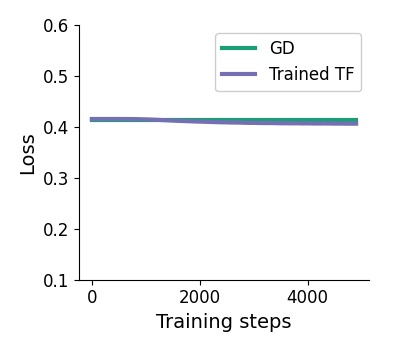

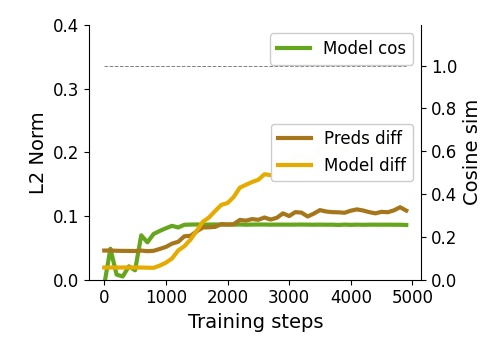

In [13]:
#@title Visualize loss and alignment measures (the printing layout is set to default and might be suboptimal)

cosine_low = 0.0
if config.num_layers == 1:
  display_learning(loss_trans_list, test=[losses_gd_list[0]], y_lim_u=0.6, y_lim_l=0.1,
                  rw=1, title="train.pdf", allow_download=False,
                  single_seeds = True, label_title ="Loss",
                  title2='GD', title1='Trained TF', 
                  title3='GD',  loc_first='upper right',
                  num_iter_os=len(loss_trans_list[0])*100)

  display_learning(cos_sim_list, grad_norm_list, p_norm_list, 
                  title1="Model cos",
                  title2="Model diff", y_lim_u=0.4,
                  title3="Preds diff", second_axis=True, color_add=0.2,
                  y_lim_u2=1.19, loc_sec='center right', single_seeds = False, 
                  y_lim_l2=cosine_low, color_axis=False, width= 5, y_label2 = 'Cosine sim',
                  rw=1, num_iter_os=len(grad_norm_list[0])*100, title="sim.pdf",
                  allow_download=False)
else:
  display_learning(loss_trans_list, gt=losses_gd_list_trained, 
                   test=[losses_gd_list[0]], y_lim_u=0.4, y_lim_l=0.0,
                   rw=1, title="train.pdf", allow_download=False,
                   title2='GD', title1='Trained TF', 
                   title3='GD$^{++}$',loc_first='upper right', x_label = "Training steps",
                   single_seeds = True, plot_title = None,
                   num_iter_os=len(loss_trans_list[0])*100)
  
  display_learning(cos_sim_list, grad_norm_list, p_norm_list, title1="Model cos",
                  title2="Model diff", y_lim_u=1.8,
                  title3="Preds diff", second_axis=True, color_add=0.2,
                  y_lim_u2=1.09999999, color_axis=False,  width= 4, x_label = "Training steps",
                  plot_title="GD vs trained TF",
                  y_lim_l2=0.5, loc_sec = 'center right', y_label1 = 'L2 Norm', y_label2 = 'Cosine sim',
                  rw=1, num_iter_os=len(loss_trans_list[0])*100, title="sim.pdf",
                  allow_download=False, plot_num=1)
  
  display_learning(cos_sim_list_o, grad_norm_list_o, p_norm_list_o, title1="Model cos",
                  title2="Model diff", y_lim_u=1.8, x_label = "Training steps", plot_title = "GD$^{++}$ vs trained TF" ,
                  title3="Preds diff", second_axis=True, color_add=0.2,
                  y_lim_u2=1.0599999, color_axis=False, width= 4, y_label1 = 'L2 Norm', y_label2 = 'Cosine sim',
                  y_lim_l2=0.7, loc_sec = 'center right',
                  rw=1, num_iter_os=len(loss_trans_list[0])*100, title="sim2.pdf",
                  allow_download=False)

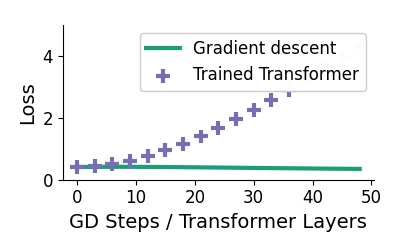

In [14]:
#@title Visualize iteratively applying a single layer Transformer layer
if config.gd_deq and config.num_heads == 1 and config.num_layers == 1:
  scale = 0.75

  train_state_final = train_state
  losses_gd, losses_tr, x_range = [], [], []

  orig_damp = config.dampening
  config.dampening = scale
  orig_num_layers = config.num_layers
  config.num_layers = 50

  config.y_update = True
  params_gd = create_weights(config.input_size, 1, config.dataset_size, lr_min*scale,
                                jax.random.normal(data_rng, shape=[1, 1, config.input_size])*0,
                              lin_diag=False,
                              gd_deq=config.gd_deq, num_layers=config.num_layers)
  x_range = np.arange(1, config.num_layers)
  

  _, _, _, rng = init()
  _, _, losses_gd = predict_test.apply(params_gd, eval_rng, eval_data, True)
  _, _, losses_gd_train = predict_test.apply(params_gd_trained, eval_rng, eval_data, True)
  _, _, losses_tr = predict_test.apply(train_state.params, eval_rng, eval_data, False)
  config.num_layers = orig_num_layers
  config.orig_damp = orig_damp
  config.y_update = False
  train_state = train_state_final

if config.gd_deq and config.deq and config.num_heads == 1:
  if orig_num_layers > 1:
      display_learning([losses_tr], gt=[losses_gd_train], test=[losses_gd], 
                      y_lim_u=10, y_lim_l=0.0,
                    rw=1, title="extra_gd_steps.pdf", allow_download=False,
                    title3='GD$^{++}$',
                    title2='GD', title1='Trained TF', 
                    line="*", height = 2.5, loc_first='lower right',
                    x_label = 'Gradient steps / TF  steps', 
                    num_iter_os=len(losses_tr))
  else:
      each = 3
      display_learning([losses_tr[0::each]], test=[losses_gd[0::each]], y_lim_u=5, y_lim_l=0.00,
                  rw=1, title="extra_gd_steps.pdf", allow_download=False,
                  #plot_title="Dampening $\lambda =$" +str(scale),
                  title3='GD$^{++}$' if config.pre_train_gd else 'GD',
                  title2='Gradient descent', title1='Trained Transformer', 
                  line="+", height = 2.5, loc_first='upper right',
                  x_label = 'GD Steps / Transformer Layers',
                  num_iter_os=len(losses_tr[0::each])*each)
  
